In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from scipy.optimize import least_squares

sys.path.insert(0, str(Path("../../nogse_pipeline/src")))
from models.model_fitting import M_ogse_free
from plotting.publication.tc_param_vars import _roi_color_map, DEFAULT_BRAIN_MARKERS


In [ ]:
MASTER_PATH  = Path("../../analysis/brains/ogse_experiments/master.long.parquet")
OUT_DIR      = Path("../../analysis/brains/ogse_experiments/lab/fit_free_vents-a1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTIONS  = ["tra", "long"]
N_LIST      = [4, 8, 12]
TD_LIST     = [76.0, 90.0, 120.0, 143.4, 210.0]      # None -> all td; list of floats -> e.g. [76.0, 90.0, 120.0]
# ROI_LIST    = ["AntCC", "MidAntCC", "CentralCC", "MidPostCC", "PostCC"]      # None -> all ROIs; list of strings -> e.g. [ "PostCC", "Left-Lateral-Ventricle"]
ROI_LIST    = ["Left-Lateral-Ventricle", "Right-Lateral-Ventricle"]
# ROI_LIST    = ["Syringe"]
G_COLUMN    = "g_thorsten"   # Gradient column used for the fit: e.g. "g", "g_thorsten", "g_lin_max"
G_CORRECTION_COLUMN = "grad_correction_factor"  # None -> use G_COLUMN directly
Y_COLUMN    = "value"        # Signal column used for the fit: "value" or "value_norm"
D0_INIT     = 3.2e-12   # m2/ms, initial seed when D0 is fitted
D0_FIXED    = None      # None -> D0 is fitted; float -> D0 is pinned [m2/ms]
D0_BOUNDS   = (0.1e-12, 10.0e-12)
# D0_GLOBAL scope — how broadly D0 is shared:
#   None          → per-curve independent fits (one D0 per td, N, direction)
#   "direction"   → one D0 per (subj, roi, direction), shared across td & N
#   "roi"         → one D0 per (subj, roi), shared across td, N & direction
#   "subj"        → one D0 per subj, shared across td, N, direction & roi
#   "all"         → one D0 for all data
D0_GLOBAL   = None
M0_FIXED    = None      # None -> M0 is fitted; float -> M0 is pinned (e.g. 1.0 to normalise)
M0_BOUNDS   = (0.0, 2000.0)
RN_FIXED    = None      # Rician noise floor (in raw signal units):
                        #   None                 → fitted per td
                        #   float                → fixed for all subj and td
                        #   {td: float}          → fixed per td, same for all subj
                        #   {subj: float}        → fixed per subj, same for all td
                        #   {subj: {td: float}}  → fixed per subj and td
                        # When set, M0 is derived as sqrt(S0² - RN²) — not a free parameter.
RN_INIT     = 10.0
RN_BOUNDS   = (0.0, 500.0)
# RN_GLOBAL scope — how broadly RN is shared when RN_FIXED is None:
#   "td"  → one RN per (subj, roi, dir, td), shared across N
#   None  → per-curve (one RN per td, N, dir)
RN_GLOBAL   = "td"

# ── Model name ─────────────────────────────────────────────────────────────────
MODEL_NAME = 'free'

In [ ]:
df = pd.read_parquet(MASTER_PATH)

data = df[
    (df.row_kind == "signal_rotated") &
    (df.direction.isin(DIRECTIONS)) &
    (df.N.isin(N_LIST)) &
    (df.stat == "avg")
].copy()

missing_cols = [col for col in [G_COLUMN, Y_COLUMN, G_CORRECTION_COLUMN] if col is not None and col not in data.columns]
if missing_cols:
    raise KeyError(f"Missing selected column(s) in data: {missing_cols}")

data["G_fit"] = data[G_COLUMN]
if G_CORRECTION_COLUMN is not None:
    data["G_fit"] = data["G_fit"] * data[G_CORRECTION_COLUMN]
data["y_raw"] = data["value"]   # raw signal (a.u.) — always needed to derive M0 from S0 and RN
data["y_fit"] = data[Y_COLUMN]

G_LABEL = f"Modulation gradient strength G [mT/m] ({G_COLUMN})"
Y_LABEL = f"{Y_COLUMN} [a.u.]"

if TD_LIST is not None:
    data = data[data.td_ms.isin(TD_LIST)]
if ROI_LIST is not None:
    data = data[data.roi.isin(ROI_LIST)]

print(f"Rows loaded: {len(data)}")
print("Groups (subj, roi, dir):", data.groupby(["subj", "roi", "direction"]).ngroups)
print(f"Gradient for fit: {G_COLUMN}" + (f" * {G_CORRECTION_COLUMN}" if G_CORRECTION_COLUMN else ""))
print(f"Signal for fit: {Y_COLUMN}")
data[["subj", "roi", "direction", "td_ms", "N", "G_fit", "y_fit"]]

In [ ]:
def _resolve_rn(subj, td):
    """Return the fixed RN for (subj, td), or None when RN_FIXED is None (→ fitted).
    RN_FIXED may be: None → free; float → global;
    {td: float} → per td; {subj: float} → per subj; {subj: {td: float}} → per subj and td.
    """
    if RN_FIXED is None:
        return None
    if isinstance(RN_FIXED, dict):
        first_key = next(iter(RN_FIXED))
        if isinstance(first_key, str):
            subj_entry = RN_FIXED.get(subj)
            if subj_entry is None:
                return 0.0
            if isinstance(subj_entry, dict):
                return float(subj_entry.get(float(td), subj_entry.get(td, 0.0)))
            return float(subj_entry)
        return float(RN_FIXED.get(float(td), RN_FIXED.get(td, 0.0)))
    return float(RN_FIXED)


def _m0_from_s0(s0_raw, rn):
    """Derive M0 from measured S0 and fixed RN: M0_true = sqrt(S0² - RN²).
    For value_norm, returns the normalized amplitude M0_true / S0_raw.
    When RN_FIXED is set this replaces M0 as a free parameter.
    """
    m0_true = np.sqrt(max(float(s0_raw)**2 - float(rn)**2, 0.0))
    if Y_COLUMN == "value_norm":
        return m0_true / float(s0_raw) if float(s0_raw) > 0 else 1.0
    return m0_true


def _rn_key(c):
    """Key for RN grouping based on RN_GLOBAL scope."""
    if RN_GLOBAL == "td":
        return (c["subj"], c["roi"], c["direction"], c["td"])
    return (c["subj"], c["roi"], c["direction"], c["td"], c["N"])


def _unpack(params, td=None, subj=None, s0=None):
    """Extract (M0, D0, RN) from the optimizer parameter vector (per-curve fit).
    When RN_FIXED is set and s0 is provided, M0 is derived rather than fitted.
    """
    idx = 0
    rn_val = _resolve_rn(subj, td)
    if M0_FIXED is not None:
        M0 = float(M0_FIXED)
    elif rn_val is not None and s0 is not None:
        M0 = _m0_from_s0(s0, rn_val)
    else:
        M0 = params[idx]; idx += 1
    if D0_FIXED is None:
        D0 = params[idx]; idx += 1
    else:
        D0 = float(D0_FIXED)
    if rn_val is None and RN_GLOBAL is None:
        RN = params[idx]
    elif rn_val is not None:
        RN = rn_val
    else:
        RN = 0.0
    return M0, D0, RN


def _free_param_names():
    """Names of the fitted optimizer parameters, in optimizer-vector order."""
    names = []
    if M0_FIXED is None and RN_FIXED is None:
        names.append("M0")
    if D0_FIXED is None:
        names.append("D0_m2ms")
    if RN_FIXED is None and RN_GLOBAL is None:
        names.append("RN")
    return names


def _fit_param_errors(result, M0, D0, RN):
    """Approximate 1-sigma parameter errors from the least-squares Jacobian."""
    errs = {"M0_err": np.nan, "D0_m2ms_err": np.nan, "RN_err": np.nan}
    n_obs = result.fun.size
    n_params = result.x.size
    dof = n_obs - n_params
    if dof <= 0 or n_params == 0:
        return errs
    try:
        cov = np.linalg.pinv(result.jac.T @ result.jac) * (2.0 * result.cost / dof)
        stderr = np.sqrt(np.maximum(np.diag(cov), 0.0))
    except np.linalg.LinAlgError:
        return errs
    for name, se in zip(_free_param_names(), stderr):
        errs[f"{name}_err"] = se
    return errs


def fit_curve(td, N, G, y, subj=None, s0=None):
    """Fit M_ogse_free for ONE (td, N) curve independently.
    When RN_FIXED is set and s0 is provided, M0 is derived from sqrt(S0²-RN²).
    """
    rn_val = _resolve_rn(subj, td)
    m0_derived = (M0_FIXED is None and rn_val is not None and s0 is not None)

    def residuals(params):
        M0, D0, RN = _unpack(params, td=td, subj=subj, s0=s0)
        with np.errstate(over="ignore", invalid="ignore"):
            sig = M_ogse_free(td, G, N, td / N, M0, D0)
            y_hat = np.sqrt(sig**2 + RN**2) if RN != 0.0 else sig
        out = y_hat - y
        return np.where(np.isfinite(out), out, 1e6)

    M0_init = float(y.max())
    x0 = []; lower = []; upper = []
    if M0_FIXED is None and not m0_derived:
        x0 += [M0_init]; lower += [M0_BOUNDS[0]]; upper += [M0_BOUNDS[1]]
    if D0_FIXED is None:
        x0 += [D0_INIT]; lower += [D0_BOUNDS[0]]; upper += [D0_BOUNDS[1]]
    if rn_val is None and RN_GLOBAL is None:
        x0 += [RN_INIT]; lower += [RN_BOUNDS[0]]; upper += [RN_BOUNDS[1]]

    if not x0:
        fun = residuals(np.array([]))
        return type("FixedResult", (), {
            "x": np.array([]),
            "fun": fun,
            "jac": np.empty((fun.size, 0)),
            "cost": 0.5 * float(np.sum(fun ** 2)),
            "success": True,
        })()

    return least_squares(residuals, x0, bounds=(lower, upper), method="trf", max_nfev=10000)


def fit_td_group(td, curves, subj=None):
    """
    Joint fit for all N curves at one (subj, roi, dir, td) with shared RN.

    Shared across N: RN (when RN_FIXED is None and RN_GLOBAL == 'td').
    Independent per N: M0 (derived from S0 if RN fixed), D0.
    Each curve dict must contain 'S0' (raw signal at G≈0).
    Returns: (result, unpack_fn) where unpack_fn(params) → (rn, m0s, d0s).
    """
    rn_fixed_val = _resolve_rn(subj, td)
    m0_derived = (M0_FIXED is None and rn_fixed_val is not None)

    def _unpack_td(params):
        idx = 0
        if rn_fixed_val is None:
            rn = float(params[idx]); idx += 1
        else:
            rn = rn_fixed_val
        m0s = {}; d0s = {}
        for c in curves:
            if m0_derived:
                m0s[c["N"]] = _m0_from_s0(c["S0"], rn)
            elif M0_FIXED is None:
                m0s[c["N"]] = float(params[idx]); idx += 1
            else:
                m0s[c["N"]] = float(M0_FIXED)
            if D0_FIXED is None:
                d0s[c["N"]] = float(params[idx]); idx += 1
            else:
                d0s[c["N"]] = float(D0_FIXED)
        return rn, m0s, d0s

    def residuals(params):
        rn, m0s, d0s = _unpack_td(params)
        res = []
        for c in curves:
            M0, D0 = m0s[c["N"]], d0s[c["N"]]
            with np.errstate(over="ignore", invalid="ignore"):
                sig = M_ogse_free(td, c["G"], c["N"], td / c["N"], M0, D0)
                y_hat = np.sqrt(sig**2 + rn**2) if rn != 0.0 else sig
            out = y_hat - c["y"]
            res.append(np.where(np.isfinite(out), out, 1e6))
        return np.concatenate(res)

    x0 = []; lower = []; upper = []
    if rn_fixed_val is None:
        x0 += [RN_INIT]; lower += [RN_BOUNDS[0]]; upper += [RN_BOUNDS[1]]
    for c in curves:
        if M0_FIXED is None and not m0_derived:
            x0 += [float(c["y"].max())]; lower += [M0_BOUNDS[0]]; upper += [M0_BOUNDS[1]]
        if D0_FIXED is None:
            x0 += [D0_INIT]; lower += [D0_BOUNDS[0]]; upper += [D0_BOUNDS[1]]

    if not x0:
        fun = residuals(np.array([]))
        result = type("FixedResult", (), {
            "x": np.array([]),
            "fun": fun,
            "jac": np.empty((fun.size, 0)),
            "cost": 0.5 * float(np.sum(fun**2)),
            "success": True,
        })()
        return result, _unpack_td

    result = least_squares(residuals, x0, bounds=(lower, upper), method="trf", max_nfev=10000)
    return result, _unpack_td


def fit_group_global_D0(group_df):
    """
    Joint fit with one D0 shared across ALL curves in group_df.

    RN scope is controlled by RN_GLOBAL:
        "td"  → one RN per (subj, roi, dir, td), shared across N
        None  → one RN per curve
    If RN_FIXED is not None, RN is pinned and M0 is derived from sqrt(S0²-RN²).

    Returns: result, curves, D0, D0_err, M0s, rn_vals, rn_errs, rn_keys_ordered
    """
    curves = []
    for (subj, roi, direction), dir_grp in group_df.groupby(["subj", "roi", "direction"]):
        tds = sorted(float(t) for t in dir_grp.td_ms.unique())
        for td in tds:
            sub = dir_grp[np.isclose(dir_grp.td_ms.astype(float), td)]
            for N in N_LIST:
                s = sub[sub.N == N].sort_values("G_fit")
                if s.empty:
                    continue
                s0_raw = float(s.loc[s.G_fit.abs() == s.G_fit.abs().min(), "y_raw"].iloc[0])
                curves.append(dict(
                    subj=subj, roi=roi, direction=direction,
                    td=td, N=int(N),
                    G=s.G_fit.values, y=s.y_fit.values, S0=s0_raw,
                ))

    rn_keys_ordered = list(dict.fromkeys(_rn_key(c) for c in curves))

    def unpack(params):
        idx = 0
        D0 = float(params[idx]) if D0_FIXED is None else float(D0_FIXED)
        if D0_FIXED is None: idx += 1

        rn_vals = {}
        if RN_FIXED is None:
            for key in rn_keys_ordered:
                rn_vals[key] = float(params[idx]); idx += 1
        else:
            for key in rn_keys_ordered:
                rn_vals[key] = _resolve_rn(key[0], key[3])

        M0s = {}
        for c in curves:
            key = (c["subj"], c["roi"], c["direction"], c["td"], c["N"])
            if M0_FIXED is not None:
                M0s[key] = float(M0_FIXED)
            elif RN_FIXED is not None:
                M0s[key] = _m0_from_s0(c["S0"], rn_vals[_rn_key(c)])
            else:
                M0s[key] = float(params[idx]); idx += 1
        return D0, rn_vals, M0s

    def residuals(params):
        D0, rn_vals, M0s = unpack(params)
        res = []
        for c in curves:
            M0 = M0s[(c["subj"], c["roi"], c["direction"], c["td"], c["N"])]
            rn = rn_vals[_rn_key(c)]
            with np.errstate(over="ignore", invalid="ignore"):
                sig = M_ogse_free(c["td"], c["G"], c["N"], c["td"] / c["N"], M0, D0)
                y_hat = np.sqrt(sig**2 + rn**2) if rn != 0.0 else sig
            out = y_hat - c["y"]
            res.append(np.where(np.isfinite(out), out, 1e6))
        return np.concatenate(res)

    x0 = []; lower = []; upper = []
    if D0_FIXED is None:
        x0 += [D0_INIT]; lower += [D0_BOUNDS[0]]; upper += [D0_BOUNDS[1]]
    if RN_FIXED is None:
        for _ in rn_keys_ordered:
            x0 += [RN_INIT]; lower += [RN_BOUNDS[0]]; upper += [RN_BOUNDS[1]]
    for c in curves:
        if M0_FIXED is None and RN_FIXED is None:
            x0 += [float(c["y"].max())]; lower += [M0_BOUNDS[0]]; upper += [M0_BOUNDS[1]]

    result = least_squares(residuals, x0, bounds=(lower, upper), method="trf", max_nfev=10000)
    D0, rn_vals, M0s = unpack(result.x)

    D0_err = np.nan
    rn_errs = {key: np.nan for key in rn_keys_ordered}
    n_obs = result.fun.size
    dof = n_obs - result.x.size
    if dof > 0 and result.x.size > 0:
        try:
            cov = np.linalg.pinv(result.jac.T @ result.jac) * (2.0 * result.cost / dof)
            stderr = np.sqrt(np.maximum(np.diag(cov), 0.0))
            err_idx = 0
            if D0_FIXED is None:
                D0_err = float(stderr[err_idx]); err_idx += 1
            if RN_FIXED is None:
                for key in rn_keys_ordered:
                    rn_errs[key] = float(stderr[err_idx]); err_idx += 1
        except np.linalg.LinAlgError:
            pass

    return result, curves, D0, D0_err, M0s, rn_vals, rn_errs, rn_keys_ordered


_D0_SCOPE_COLS = {
    "direction": ["subj", "roi", "direction"],
    "roi":       ["subj", "roi"],
    "subj":      ["subj"],
    "all":       [],
}

In [ ]:
rows      = []
fit_store = {}

if D0_GLOBAL is None:
    for (subj, roi, direction), grp in data.groupby(["subj", "roi", "direction"]):
        tds = sorted(float(t) for t in grp.td_ms.unique())
        fit_store[(subj, roi, direction)] = {"tds": tds, "fits": {td: {} for td in tds}}

        if RN_GLOBAL == "td" and RN_FIXED is None:
            # Shared RN per (subj, roi, dir, td); per-N M0 and D0
            for td in tds:
                sub = grp[np.isclose(grp.td_ms.astype(float), td)]
                td_curves = []
                for N in N_LIST:
                    s = sub[sub.N == N].sort_values("G_fit")
                    if s.empty:
                        continue
                    s0_raw = float(s.loc[s.G_fit.abs() == s.G_fit.abs().min(), "y_raw"].iloc[0])
                    td_curves.append(dict(N=int(N), G=s.G_fit.values, y=s.y_fit.values, S0=s0_raw))
                if not td_curves:
                    continue

                result, _unpack_td = fit_td_group(td, td_curves, subj=subj)
                rn, m0s, d0s = _unpack_td(result.x)

                rn_err = np.nan
                d0_errs = {c["N"]: np.nan for c in td_curves}
                m0_errs = {c["N"]: np.nan for c in td_curves}
                n_obs = result.fun.size; n_params = result.x.size; dof = n_obs - n_params
                if dof > 0 and n_params > 0:
                    try:
                        cov = np.linalg.pinv(result.jac.T @ result.jac) * (2.0 * result.cost / dof)
                        stderr = np.sqrt(np.maximum(np.diag(cov), 0.0))
                        err_idx = 0
                        if RN_FIXED is None:
                            rn_err = float(stderr[err_idx]); err_idx += 1
                        for c in td_curves:
                            if M0_FIXED is None:
                                m0_errs[c["N"]] = float(stderr[err_idx]); err_idx += 1
                            if D0_FIXED is None:
                                d0_errs[c["N"]] = float(stderr[err_idx]); err_idx += 1
                    except np.linalg.LinAlgError:
                        pass

                print(
                    f"{subj:6s}  {roi:25s}  {direction}  td={td:5.0f} ms  "
                    f"RN={rn:.4f}  cost={result.cost:.3e}"
                )
                for c in td_curves:
                    N = c["N"]; M0 = m0s[N]; D0 = d0s[N]
                    fit_store[(subj, roi, direction)]["fits"][td][N] = dict(
                        G=c["G"], y=c["y"], M0=M0, D0=D0, RN=rn, S0=c["S0"]
                    )
                    rows.append(dict(
                        subj=subj, roi=roi, direction=direction,
                        td_ms=td, N=N,
                        M0=M0, D0_m2ms=D0, RN=rn,
                        M0_err=m0_errs[N], D0_m2ms_err=d0_errs[N], RN_err=rn_err,
                        model_name=MODEL_NAME,
                        g_column=G_COLUMN, g_correction_column=G_CORRECTION_COLUMN, y_column=Y_COLUMN,
                        cost=float(result.cost), success=bool(result.success),
                    ))
        else:
            # Per-curve fits (also covers RN_GLOBAL=="td" with fixed RN: M0 derived per curve)
            for td in tds:
                sub = grp[np.isclose(grp.td_ms.astype(float), td)]
                for N in N_LIST:
                    s = sub[sub.N == N].sort_values("G_fit")
                    if s.empty:
                        continue
                    G, y = s.G_fit.values, s.y_fit.values
                    s0_raw = float(s.loc[s.G_fit.abs() == s.G_fit.abs().min(), "y_raw"].iloc[0])
                    result = fit_curve(td, N, G, y, subj=subj, s0=s0_raw)
                    M0, D0, RN = _unpack(result.x, td=td, subj=subj, s0=s0_raw)
                    param_errs = _fit_param_errors(result, M0, D0, RN)
                    print(
                        f"{subj:6s}  {roi:25s}  {direction}  td={td:5.0f} ms  N={N}  "
                        f"M0={M0:.4f}  D0={D0:.3e} m2/ms  RN={RN:.4f}  cost={result.cost:.3e}"
                    )
                    fit_store[(subj, roi, direction)]["fits"][td][N] = dict(
                        G=G, y=y, M0=M0, D0=D0, RN=RN, S0=s0_raw
                    )
                    rows.append(dict(
                        subj=subj, roi=roi, direction=direction,
                        td_ms=td, N=N,
                        M0=M0, D0_m2ms=D0, RN=RN,
                        **param_errs,
                        model_name=MODEL_NAME,
                        g_column=G_COLUMN, g_correction_column=G_CORRECTION_COLUMN, y_column=Y_COLUMN,
                        cost=float(result.cost), success=bool(result.success),
                    ))

else:
    scope_cols = _D0_SCOPE_COLS[D0_GLOBAL]
    groups = data.groupby(scope_cols) if scope_cols else [("all", data)]

    for group_key, group_df in groups:
        result, curves, D0_global, D0_err, M0s, rn_vals, rn_errs, rn_keys_ordered = fit_group_global_D0(group_df)

        key_str = group_key if isinstance(group_key, str) else (
            "  ".join(str(k) for k in group_key) if isinstance(group_key, tuple) else str(group_key)
        )
        print(f"[{key_str}]  D0={D0_global:.3e} m2/ms  cost={result.cost:.3e}")

        for (subj, roi, direction), sub_grp in group_df.groupby(["subj", "roi", "direction"]):
            if (subj, roi, direction) not in fit_store:
                tds_srd = sorted(float(t) for t in sub_grp.td_ms.unique())
                fit_store[(subj, roi, direction)] = {"tds": tds_srd, "fits": {t: {} for t in tds_srd}}

        for c in curves:
            subj, roi, direction, td, N = c["subj"], c["roi"], c["direction"], c["td"], c["N"]
            M0  = M0s[(subj, roi, direction, td, N)]
            rn  = rn_vals[_rn_key(c)]
            rn_err = rn_errs.get(_rn_key(c), np.nan)
            fit_store[(subj, roi, direction)]["fits"][td][N] = dict(
                G=c["G"], y=c["y"], M0=M0, D0=D0_global, RN=rn, S0=c["S0"]
            )
            rows.append(dict(
                subj=subj, roi=roi, direction=direction,
                td_ms=td, N=N,
                M0=M0, D0_m2ms=D0_global, RN=rn,
                M0_err=np.nan, D0_m2ms_err=D0_err, RN_err=rn_err,
                model_name=MODEL_NAME,
                g_column=G_COLUMN, g_correction_column=G_CORRECTION_COLUMN, y_column=Y_COLUMN,
                cost=float(result.cost), success=bool(result.success),
            ))

In [18]:
results_df = pd.DataFrame(rows)
results_df.to_excel(OUT_DIR / "fit_results.xlsx", index=False)
print(f"Saved {len(results_df)} rows to {OUT_DIR / 'fit_results.xlsx'}")
results_df

Saved 156 rows to ../../analysis/brains/ogse_experiments/lab/fit_free_vents-a1/fit_results.xlsx


,subj,roi,direction,td_ms,N,M0,D0_m2ms,RN,M0_err,D0_m2ms_err,RN_err,model_name,g_column,g_correction_column,y_column,cost,success
0,BRAIN,Left-Lateral-Ventricle,long,76.0,4,1079.607938,3.018213e-12,129.027197,3.149834e-28,2.466635e-14,2.182040e-28,free,g_thorsten,grad_correction_factor,value,152.515726,True
1,BRAIN,Left-Lateral-Ventricle,long,76.0,8,1117.384248,2.763589e-12,129.027197,5.400195e-28,2.926682e-14,2.182040e-28,free,g_thorsten,grad_correction_factor,value,152.515726,True
2,BRAIN,Left-Lateral-Ventricle,long,76.0,12,1081.977511,2.006918e-12,129.027197,1.291643e-27,4.366051e-14,2.182040e-28,free,g_thorsten,grad_correction_factor,value,152.515726,True
3,BRAIN,Left-Lateral-Ventricle,long,90.0,4,1246.506665,2.849689e-12,64.526693,6.022209e-28,5.902608e-14,1.910459e-28,free,g_thorsten,grad_correction_factor,value,910.509478,True
4,BRAIN,Left-Lateral-Ventricle,long,90.0,8,1250.164869,2.918057e-12,64.526693,5.501187e-28,4.870909e-14,1.910459e-28,free,g_thorsten,grad_correction_factor,value,910.509478,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,MBBL,Right-Lateral-Ventricle,tra,143.4,8,1431.800428,2.780864e-12,55.644009,7.864031e-28,9.154003e-14,2.885162e-28,free,g_thorsten,grad_correction_factor,value,2821.284979,True
152,MBBL,Right-Lateral-Ventricle,tra,143.4,12,1430.172034,2.769032e-12,55.644009,6.580854e-28,7.588357e-14,2.885162e-28,free,g_thorsten,grad_correction_factor,value,2821.284979,True
153,MBBL,Right-Lateral-Ventricle,tra,210.0,4,1491.087939,3.005694e-12,49.989807,5.238833e-28,6.316637e-14,1.422091e-28,free,g_thorsten,grad_correction_factor,value,542.175395,True
154,MBBL,Right-Lateral-Ventricle,tra,210.0,8,1482.529758,3.003870e-12,49.989807,4.181622e-28,5.016230e-14,1.422091e-28,free,g_thorsten,grad_correction_factor,value,542.175395,True


In [19]:
G_plot = np.linspace(0, float(data.G_fit.max()), 300)

for (subj, roi, direction), store in fit_store.items():
    tds   = store["tds"]
    n_tds = len(tds)

    fig, axes_grid = plt.subplots(2, n_tds, figsize=(4 * n_tds, 7), sharey="row", squeeze=False)
    axes      = axes_grid[0]
    diff_axes = axes_grid[1]

    for ax, dax, td in zip(axes, diff_axes, tds):
        fits_td = store["fits"][td]
        title_lines = [f"td = {td:.1f} ms"]
        y_hat_per_N = {}
        for N, color in zip(N_LIST, ["C0", "C1", "C2", "C3"]):
            fit = fits_td.get(N)
            if fit is None:
                continue
            ax.scatter(fit["G"], fit["y"], color=color, s=20, zorder=3, label=f"N={N} data")
            rn = fit.get("RN", 0.0)
            with np.errstate(over="ignore", invalid="ignore"):
                sig = M_ogse_free(td, G_plot, N, td / N, fit["M0"], fit["D0"])
                y_hat = np.sqrt(sig**2 + rn**2) if rn != 0.0 else sig
            y_hat_per_N[N] = y_hat
            ax.plot(G_plot, y_hat, color=color, label=f"N={N} fit")
            title_lines.append(f"D0(N={N}) = {fit['D0']:.2e} m2/ms  RN={rn:.3f}")
        ax.set_title("\n".join(title_lines), fontsize=7)
        ax.set_xlabel(G_LABEL)
        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        if 8 in y_hat_per_N and 4 in y_hat_per_N:
            dax.plot(G_plot, y_hat_per_N[8] - y_hat_per_N[4], color="k")
            dax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
        dax.set_title(f"td = {td:.1f} ms  (N=8 − N=4)", fontsize=8)
        dax.set_xlabel(G_LABEL)
        dax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
        dax.set_axisbelow(True)

    axes[0].set_ylabel(Y_LABEL)
    diff_axes[0].set_ylabel("ΔS  (N=8 − N=4)")
    axes[0].legend(fontsize=6)
    fig.suptitle(f"{subj}  |  {roi}  |  {direction}", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Fit plots saved.")


Fit plots saved.


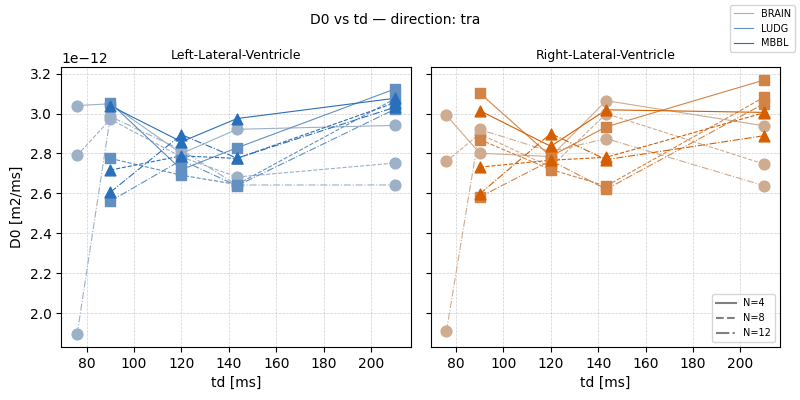

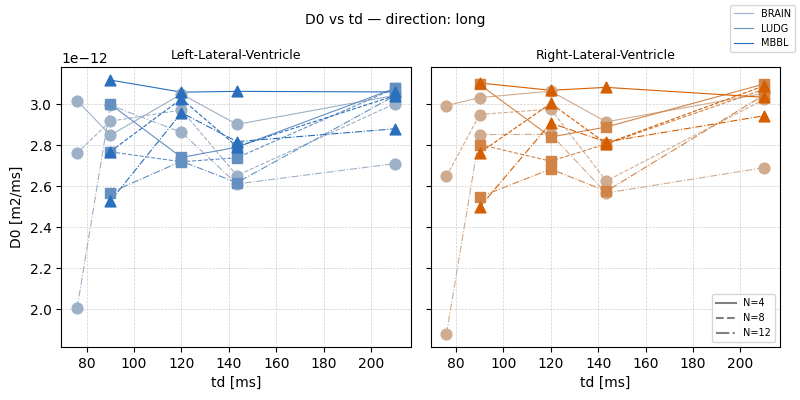

In [20]:
rois     = sorted(results_df.roi.unique())
subjects = sorted(results_df.subj.unique())
roi_colors = _roi_color_map(rois)
_N_ls        = ["-", "--", "-.", ":"]
N_linestyles = {N: ls for N, ls in zip(N_LIST, _N_ls)}

for direction in DIRECTIONS:
    sub = results_df[results_df.direction == direction]
    fig, axes = plt.subplots(1, len(rois), figsize=(4 * len(rois), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, roi in zip(axes, rois):
        base_color = roi_colors[roi]
        cmap = mcolors.LinearSegmentedColormap.from_list("", ["#cccccc", base_color])
        for i, subj in enumerate(subjects):
            shade = cmap(0.3 + 0.7 * i / max(1, len(subjects) - 1))
            marker = DEFAULT_BRAIN_MARKERS[i % len(DEFAULT_BRAIN_MARKERS)]
            for N in N_LIST:
                g = (
                    sub[(sub.roi == roi) & (sub.subj == subj) & (sub.N == N)]
                    .drop_duplicates("td_ms")
                    .sort_values("td_ms")
                )
                if g.empty:
                    continue
                label = subj if N == N_LIST[0] else None
                ax.scatter(g.td_ms, g.D0_m2ms, color=shade, marker=marker, s=60, zorder=3)
                ax.plot(g.td_ms, g.D0_m2ms, color=shade, linewidth=0.8,
                        linestyle=N_linestyles[N], label=label)
        ax.set_title(roi, fontsize=9)
        ax.set_xlabel("td [ms]")
        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("D0 [m2/ms]")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, fontsize=7, loc="upper right", ncol=1)
    n_handles = [mlines.Line2D([], [], color="gray", linestyle=N_linestyles[N], label=f"N={N}") for N in N_LIST]
    axes[-1].legend(handles=n_handles, fontsize=7, loc="lower right")
    fig.suptitle(f"D0 vs td — direction: {direction}", fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"D0_vs_td_{direction}.png", dpi=120)
    plt.show()

In [ ]:
for (subj, roi, direction), store in fit_store.items():
    tds   = store["tds"]
    n_tds = len(tds)

    fig, axes_grid = plt.subplots(2, n_tds, figsize=(4 * n_tds, 7), sharey="row", squeeze=False)
    axes      = axes_grid[0]
    diff_axes = axes_grid[1]

    for ax, dax, td in zip(axes, diff_axes, tds):
        fits_td = store["fits"][td]
        y_hat_per_N = {}
        for N, color in zip(N_LIST, ["C0", "C1", "C2", "C3"]):
            fit = fits_td.get(N)
            if fit is None:
                continue
            M0 = fit["M0"] if fit["M0"] != 0.0 else 1.0
            ax.scatter(fit["G"], fit["y"] / M0, color=color, s=20, zorder=3, label=f"N={N} data")
            with np.errstate(over="ignore", invalid="ignore"):
                sig_norm = M_ogse_free(td, G_plot, N, td / N, 1.0, fit["D0"])
            y_hat_per_N[N] = sig_norm
            ax.plot(G_plot, sig_norm, color=color, label=f"N={N} model")
        ax.set_title(f"td = {td:.1f} ms", fontsize=8)
        ax.set_xlabel(G_LABEL)
        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        if 8 in y_hat_per_N and 4 in y_hat_per_N:
            dax.plot(G_plot, y_hat_per_N[8] - y_hat_per_N[4], color="k")
            dax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
        dax.set_title(f"td = {td:.1f} ms  (N=8 − N=4)", fontsize=8)
        dax.set_xlabel(G_LABEL)
        dax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
        dax.set_axisbelow(True)

    axes[0].set_ylabel(f"{Y_COLUMN} / M0 [a.u.]")
    diff_axes[0].set_ylabel("ΔS  (N=8 − N=4)")
    axes[0].legend(fontsize=6)
    fig.suptitle(f"{subj}  |  {roi}  |  {direction}  |  clean model (no RN)", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fit_norm_{subj}_{roi}_{direction}.png", dpi=120)
    plt.close(fig)

print("Clean model fit plots saved.")


In [22]:
subjects_plot = sorted(results_df.subj.unique())
rois_plot     = sorted(results_df.roi.unique())
Ns_plot       = sorted(results_df.N.unique())
dirs_plot     = [d for d in ["long", "tra"] if d in results_df.direction.unique()]
roi_colors_p  = _roi_color_map(rois_plot)
_N_ls_p       = ["-", "--", "-.", ":"]
N_ls          = {N: _N_ls_p[i % len(_N_ls_p)] for i, N in enumerate(Ns_plot)}

for subj in subjects_plot:
    for param, ylabel in [("M0", "M0 [a.u.]"), ("D0_m2ms", "D0 [m2/ms]")]:
        fig, axes = plt.subplots(
            len(rois_plot), len(dirs_plot),
            figsize=(4 * len(dirs_plot), 3 * len(rois_plot)),
            sharey=False, squeeze=False
        )
        for i_roi, roi in enumerate(rois_plot):
            for i_dir, direction in enumerate(dirs_plot):
                ax = axes[i_roi, i_dir]
                sub = results_df[
                    (results_df.subj == subj) &
                    (results_df.roi == roi) &
                    (results_df.direction == direction)
                ]
                for N in Ns_plot:
                    g = sub[sub.N == N].sort_values("td_ms")
                    if g.empty:
                        continue
                    line, = ax.plot(g.td_ms, g[param], linestyle=N_ls[N],
                                    marker="o", ms=4, linewidth=0.8, label=f"N={N}")
                    err_col = f"{param}_err"
                    if err_col in g.columns:
                        x = g.td_ms.to_numpy(dtype=float)
                        y = g[param].to_numpy(dtype=float)
                        yerr = g[err_col].to_numpy(dtype=float)
                        ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
                        if np.any(ok):
                            ax.fill_between(
                                x[ok], y[ok] - yerr[ok], y[ok] + yerr[ok],
                                color=line.get_color(), alpha=0.18, linewidth=0
                            )
                if i_roi == 0:
                    ax.set_title(direction, fontsize=9)
                if i_dir == 0:
                    ax.set_ylabel(f"{roi}\n{ylabel}", fontsize=8)
                ax.set_xlabel("td [ms]")
                ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
                ax.set_axisbelow(True)
                if i_roi == 0 and i_dir == len(dirs_plot) - 1:
                    ax.legend(fontsize=6, title="N", title_fontsize=6)
        fig.suptitle(f"{subj} — {param} vs td", fontsize=11)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_{subj}.png", dpi=120)
        # plt.show()
        plt.close(fig)

In [23]:
for subj in subjects_plot:
    for param, ylabel in [("M0", "M0 [a.u.]"), ("D0_m2ms", "D0 [m2/ms]")]:
        fig, axes = plt.subplots(
            len(rois_plot), len(dirs_plot),
            figsize=(4 * len(dirs_plot), 3 * len(rois_plot)),
            sharey=False, squeeze=False
        )
        for i_roi, roi in enumerate(rois_plot):
            for i_dir, direction in enumerate(dirs_plot):
                ax = axes[i_roi, i_dir]
                sub = results_df[
                    (results_df.subj == subj) &
                    (results_df.roi == roi) &
                    (results_df.direction == direction)
                ]
                for N in Ns_plot:
                    g = sub[sub.N == N].sort_values("td_ms")
                    if g.empty:
                        continue
                    line, = ax.plot(g.td_ms, g[param], linestyle=N_ls[N],
                                    marker="o", ms=4, linewidth=0.8, label=f"N={N}")
                    err_col = f"{param}_err"
                    if err_col in g.columns:
                        x = g.td_ms.to_numpy(dtype=float)
                        y = g[param].to_numpy(dtype=float)
                        yerr = g[err_col].to_numpy(dtype=float)
                        lower = np.maximum(y - yerr, np.finfo(float).tiny)
                        upper = y + yerr
                        ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (y > 0) & (upper > 0)
                        if np.any(ok):
                            ax.fill_between(
                                x[ok], lower[ok], upper[ok],
                                color=line.get_color(), alpha=0.18, linewidth=0
                            )
                ax.set_yscale("log")
                if i_roi == 0:
                    ax.set_title(direction, fontsize=9)
                if i_dir == 0:
                    ax.set_ylabel(f"{roi}\n{ylabel} (log)", fontsize=8)
                ax.set_xlabel("td [ms]")
                ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
                ax.set_axisbelow(True)
                if i_roi == 0 and i_dir == len(dirs_plot) - 1:
                    ax.legend(fontsize=6, title="N", title_fontsize=6)
        fig.suptitle(f"{subj} — {param} vs td  (log scale)", fontsize=11)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f"{param}_vs_td_log_{subj}.png", dpi=120)
        # plt.show()
        plt.close(fig)

In [ ]:
# ── Per-subject contrast figures: ROIs × directions, contrast curves per td ──
# _raw  = full fit including RN noise:  sqrt(sig² + rn²)
# _corr = clean model, no noise:        sig
td_cmap    = plt.cm.viridis
N_hi, N_lo = 8, 4
G_plot     = np.linspace(0, float(data.G_fit.max()), 300)
PEAK_GAMMA = 267.5221900   # rad / (ms · mT), proton gyromagnetic ratio

def _x_for_td(td_ms, xvar):
    if xvar == "G":
        return G_plot.copy()
    D0, gamma = float(D0_PLOT), float(PEAK_GAMMA)
    l_d = np.sqrt(D0 * float(td_ms))
    l_G = np.full_like(G_plot, np.nan)
    valid = G_plot > 0
    l_G[valid] = (D0 / (gamma * G_plot[valid])) ** (1.0 / 3.0)
    Ld  = l_d / l_G
    Lcf = 1.5 ** 0.25 / np.sqrt(Ld)
    lcf = Lcf * l_G * 1e6
    if xvar == "Ld":  return Ld
    if xvar == "Lcf": return Lcf
    if xvar == "lcf": return lcf
    raise ValueError(xvar)

X_AXES = [
    ("G",   G_LABEL),
    ("Ld",  "Lᵈ (dimensionless)"),
    ("Lcf", "Lcf (dimensionless)"),
    ("lcf", "lcf [µm]"),
]

D0_PLOT = D0_INIT  # D0_FIXED is None; use D0_INIT as reference for x-axis transforms

# ── precompute contrasts ───────────────────────────────────────────────────────
raw_contrast_store  = {}   # sqrt(sig² + rn²)
corr_contrast_store = {}   # sig only

for (subj, roi, direction), store in fit_store.items():
    for td in store["tds"]:
        raw_per_N  = {}
        corr_per_N = {}
        for N in N_LIST:
            fit = store["fits"][td].get(N)
            if fit is None:
                continue
            rn = fit.get("RN", 0.0)
            with np.errstate(over="ignore", invalid="ignore"):
                sig   = M_ogse_free(td, G_plot, N, td / N, fit["M0"], fit["D0"])
                y_hat = np.sqrt(sig**2 + rn**2) if rn != 0.0 else sig
            raw_per_N[N]  = y_hat
            corr_per_N[N] = sig
        if N_hi in raw_per_N and N_lo in raw_per_N:
            raw_contrast_store[(subj, roi, direction, td)]  = raw_per_N[N_hi]  - raw_per_N[N_lo]
        if N_hi in corr_per_N and N_lo in corr_per_N:
            corr_contrast_store[(subj, roi, direction, td)] = corr_per_N[N_hi] - corr_per_N[N_lo]

# ── helper ─────────────────────────────────────────────────────────────────────
def _plot_contrast(cstore, xvar, xlabel, subj, suffix, title_tag):
    rois_subj = sorted(set(k[1] for k in cstore if k[0] == subj))
    dirs_subj = [d for d in DIRECTIONS if any(k[2] == d for k in cstore if k[0] == subj)]
    n_rois, n_dirs = len(rois_subj), len(dirs_subj)
    if n_rois == 0 or n_dirs == 0:
        return
    all_tds_subj = sorted(set(k[3] for k in cstore if k[0] == subj))
    colors_leg   = [td_cmap(i / max(1, len(all_tds_subj) - 1)) for i in range(len(all_tds_subj))]
    leg_handles  = [plt.Line2D([0], [0], color=c, linewidth=1.5) for c in colors_leg]
    leg_labels   = [f"td={td:.0f} ms" for td in all_tds_subj]
    td_color_map = {td: c for td, c in zip(all_tds_subj, colors_leg)}
    fig, axes = plt.subplots(n_rois, n_dirs, figsize=(4 * n_dirs, 3 * n_rois), squeeze=False)
    for i_roi, roi in enumerate(rois_subj):
        for i_dir, direction in enumerate(dirs_subj):
            ax = axes[i_roi, i_dir]
            tds_here = sorted(k[3] for k in cstore
                              if k[0] == subj and k[1] == roi and k[2] == direction)
            if not tds_here:
                ax.set_visible(False)
                continue
            for td in tds_here:
                ax.plot(_x_for_td(td, xvar), cstore[(subj, roi, direction, td)],
                        color=td_color_map[td], linewidth=1.2)
            ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
            if i_roi == 0:
                ax.set_title(direction, fontsize=9)
            if i_dir == 0:
                ax.set_ylabel(f"{roi}\nΔS (N={N_hi}−N={N_lo})", fontsize=7)
            ax.set_xlabel(xlabel, fontsize=7)
            ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)
            ax.set_axisbelow(True)
            ax.tick_params(labelsize=6)
    fig.suptitle(f"{subj} — contrast ΔS (N={N_hi}−N={N_lo}) vs {xvar}  [{title_tag}]", fontsize=10)
    fig.legend(leg_handles, leg_labels,
               loc="upper center", ncol=len(leg_labels), fontsize=7, frameon=False,
               bbox_to_anchor=(0.5, 1.04), bbox_transform=fig.transFigure)
    fig.tight_layout(rect=[0, 0, 1, 0.87])
    fig.savefig(OUT_DIR / f"contrast_vs_{xvar}_{subj}_{suffix}.png", dpi=120, bbox_inches="tight")
    plt.close(fig)

# ── generate _raw and _corr figures ───────────────────────────────────────────
all_subjs = sorted(set(k[0] for k in raw_contrast_store))
for xvar, xlabel in X_AXES:
    for subj in all_subjs:
        _plot_contrast(raw_contrast_store,  xvar, xlabel, subj, "raw",  "fit w/ RN")
        _plot_contrast(corr_contrast_store, xvar, xlabel, subj, "corr", "clean model")

print("Per-subject contrast figures saved (_raw and _corr).")
